# Arquitetura Própria — GTSRB
Experimento opcional - comparação do baseline com uma arquitetura híbrida que combina ideias dos experimentos do grupo (ResNet-18 e VGG-like)

In [4]:
!pip install -q torch torchvision seaborn

### 1. SETUP

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import copy
import json
from typing import Optional

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions


In [6]:
model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
    os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

os.makedirs("figuras", exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Hiperparâmetros

In [7]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40
LR = 1e-3


In [8]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


100%|██████████| 187M/187M [00:16<00:00, 11.5MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.56MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 219kB/s]


Usando dispositivo: cuda


In [9]:
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"train_loader = {len(train_loader)} batches")
print(f"val_loader = {len(val_loader)} batches")
print(f"test_loader = {len(test_loader)} batches")

for x, y in train_loader:
    print("Formato das imagens:", x.shape)
    print("Formato dos rótulos:", y.shape)
    break


NUM_CLASSES = 43
train_loader = 167 batches
val_loader = 42 batches
test_loader = 99 batches
Formato das imagens: torch.Size([128, 3, 32, 32])
Formato dos rótulos: torch.Size([128])


### 3. Modelo rede neural

### 3.1 Classe para Rede Neural - Baseline (EHMNet)

In [10]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x


### 3.2 Classe para Rede Neural - Arquitetura Própria (Mesclagem)

**Ideia de design:** essa arquitetura combina técnicas usadas em outros experimentos do grupo:

- **Bloco residual com conexão de atalho** (ideia do experimento ResNet-18) -- a entrada de cada bloco é somada de volta à saída, o que ajuda o gradiente a fluir melhor em redes mais profundas
- **Dois convs 3x3 empilhados por bloco + BatchNorm após cada um** (ideia do experimento VGG-like)
- **Global Average Pooling** em vez de Flatten + FC grande (ideia do ResNet-18) -- reduz bastante o número de parâmetros antes da classificação
- **Dropout** antes da camada final (ideia da arquitetura própria original)

Diferente da ResNet-18 completa do grupo (4 estágios, até 512 canais), aqui usamos só 3 estágios e canais bem mais modestos (32→64→128), na mesma escala do baseline -- a ideia é testar as *técnicas*, não só ganhar por ter uma rede gigante.

In [11]:
class BasicBlock(nn.Module):
    """Bloco residual: dois convs 3x3 + BatchNorm, com conexão de atalho (skip connection)."""
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: Optional[nn.Module] = None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample  # projecao 1x1 quando muda resolucao/canais

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # conexao residual
        out = self.relu(out)
        return out


class EHMNet_Mesclagem(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32, dropout: float = 0.5):
        super().__init__()
        self.stem_conv = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.stage1 = self._make_stage(32, 32, stride=1)    # 32x32
        self.stage2 = self._make_stage(32, 64, stride=2)    # 16x16
        self.stage3 = self._make_stage(64, 128, stride=2)   # 8x8

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    @staticmethod
    def _make_stage(in_channels, out_channels, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        return BasicBlock(in_channels, out_channels, stride, downsample)

    def forward(self, x):
        x = self.relu(self.stem_bn(self.stem_conv(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"EHMNet (baseline)    : {count_params(EHMNet()):>10,} parâmetros")
print(f"EHMNet_Mesclagem     : {count_params(EHMNet_Mesclagem()):>10,} parâmetros")


EHMNet (baseline)    :  1,079,275 parâmetros
EHMNet_Mesclagem     :    312,907 parâmetros


### 4. Funções para Cálculo e Comparação das Métricas

In [12]:
def train_one_epoch(trainloader, model, criterion, optimizer, device) -> tuple[float, float]:
    model.train()  # ativa o modo de treino (importante por causa da BatchNorm)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total


def validate(val_loader, model, criterion, device) -> tuple[float, float]:
    model.eval()  # ativa o modo de avaliacao
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total


def get_confusion_matrix(loader, model, device, num_class=NUM_CLASSES) -> torch.Tensor:
    model.eval()
    cm = torch.zeros(num_class, num_class, dtype=torch.int64)

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            for t, p in zip(labels, predicted):
                cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, title='Matriz de Confusão', save_path=None, ax=None):
    nomes_classes = [GTSRB_CLASSES[i] for i in range(NUM_CLASSES)]
    standalone = ax is None
    if standalone:
        plt.figure(figsize=(12, 10))
        ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=ax)

    ax.set_ylabel('Valores Reais')
    ax.set_xlabel('Valores Previstos')
    ax.set_title(title)

    if standalone:
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


def predict(loader, model, device):
    model.eval()
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)
    return np.concatenate(ytrue), np.concatenate(ypred)


def per_class_accuracy(y_true, y_pred, num_classes=NUM_CLASSES) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        accs[c] = float((y_pred[mask] == c).sum()) / total if total > 0 else float('nan')
    return accs


def relatorio_por_classe(cm, class_names=GTSRB_CLASSES, nome_modelo=""):
    cm = cm.numpy() if hasattr(cm, "numpy") else np.asarray(cm)
    suporte = cm.sum(axis=1)
    acertos = np.diag(cm)
    acc_classe = np.divide(acertos, suporte,
                           out=np.zeros(len(cm), dtype=float), where=suporte > 0)

    overall = acertos.sum() / cm.sum()
    macro_acc = acc_classe.mean()

    df = pd.DataFrame({
        "classe":   [class_names[i] for i in range(len(cm))],
        "suporte":  suporte.astype(int),
        "acertos":  acertos.astype(int),
        "acuracia": acc_classe.round(4),
    })

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia global (overall): {overall:.4f}")
    print(f"Macro accuracy (média por classe): {macro_acc:.4f}\n")
    print("5 piores classes:")
    print(df.sort_values("acuracia").head(5).to_string(index=False))
    print()
    print("5 melhores classes:")
    print(df.sort_values("acuracia", ascending=False).head(5).to_string(index=False))
    print()
    return df, overall, macro_acc


### Funções de salvamento e carregamento de modelos

In [13]:
def save_model_state(state_dict, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(state_dict, PATH)
    return PATH


def load_model(file_name, model_class, path=model_pth_path, **kwargs):
    PATH = f'{path}/{file_name}'
    model = model_class(**kwargs)
    model.load_state_dict(torch.load(PATH))
    return model


### 5. Função de treino completo (Baseline e Mesclagem)

In [14]:
def run_experiment(model, model_name, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 3 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    checkpoint_path = save_model_state(best_state, f"{model_name}.pt")

    best_model = model.__class__(num_classes=NUM_CLASSES).to(device)
    best_model.load_state_dict(best_state)
    best_model.eval()

    print(f"\nMelhor acurácia de validação: {best_val_acc:.4f} (época {best_epoch})")

    return {
        "name": model_name,
        "model": best_model,
        "history": history,
        "checkpoint_path": checkpoint_path,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
    }


### 6. Experimento Opcional - Treinando Baseline

In [15]:
model_baseline = EHMNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_baseline = run_experiment(model_baseline, "ehmnet_baseline_opcional", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_baseline_opcional] Epoch 01/40 | Train Loss: 1.5401 | Train Acc: 0.5673 | Val Loss: 0.4443 | Val Acc: 0.8754
[ehmnet_baseline_opcional] Epoch 03/40 | Train Loss: 0.1144 | Train Acc: 0.9710 | Val Loss: 0.1170 | Val Acc: 0.9717
[ehmnet_baseline_opcional] Epoch 06/40 | Train Loss: 0.0270 | Train Acc: 0.9931 | Val Loss: 0.0540 | Val Acc: 0.9880
[ehmnet_baseline_opcional] Epoch 09/40 | Train Loss: 0.0123 | Train Acc: 0.9967 | Val Loss: 0.0745 | Val Acc: 0.9792
[ehmnet_baseline_opcional] Epoch 12/40 | Train Loss: 0.0034 | Train Acc: 0.9994 | Val Loss: 0.0308 | Val Acc: 0.9942
[ehmnet_baseline_opcional] Epoch 15/40 | Train Loss: 0.0221 | Train Acc: 0.9933 | Val Loss: 0.0345 | Val Acc: 0.9934
[ehmnet_baseline_opcional] Epoch 18/40 | Train Loss: 0.0110 | Train Acc: 0.9973 | Val Loss: 0.0342 | Val Acc: 0.9929
[ehmnet_baseline_opcional] Epoch 21/40 | Train Loss: 0.0122 | Train Acc: 0.9969 | Val Loss: 0.0270 | Val Acc: 0.9949
[ehmnet_baseline_opcional] Epoch 24/40 | Train Loss: 0.0002 | Tr

### 6. Experimento Opcional - Treinando Arquitetura Própria (Mesclagem)

In [16]:
model_mesclagem = EHMNet_Mesclagem(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_mesclagem = run_experiment(model_mesclagem, "ehmnet_mesclagem", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_mesclagem] Epoch 01/40 | Train Loss: 2.6835 | Train Acc: 0.2687 | Val Loss: 1.9573 | Val Acc: 0.4349
[ehmnet_mesclagem] Epoch 03/40 | Train Loss: 0.7177 | Train Acc: 0.8137 | Val Loss: 0.4133 | Val Acc: 0.9152
[ehmnet_mesclagem] Epoch 06/40 | Train Loss: 0.0979 | Train Acc: 0.9848 | Val Loss: 0.2314 | Val Acc: 0.9245
[ehmnet_mesclagem] Epoch 09/40 | Train Loss: 0.0393 | Train Acc: 0.9940 | Val Loss: 0.0617 | Val Acc: 0.9827
[ehmnet_mesclagem] Epoch 12/40 | Train Loss: 0.0251 | Train Acc: 0.9962 | Val Loss: 0.0562 | Val Acc: 0.9829
[ehmnet_mesclagem] Epoch 15/40 | Train Loss: 0.0182 | Train Acc: 0.9972 | Val Loss: 0.0105 | Val Acc: 0.9968
[ehmnet_mesclagem] Epoch 18/40 | Train Loss: 0.0159 | Train Acc: 0.9970 | Val Loss: 0.1949 | Val Acc: 0.9407
[ehmnet_mesclagem] Epoch 21/40 | Train Loss: 0.0092 | Train Acc: 0.9986 | Val Loss: 0.0094 | Val Acc: 0.9962
[ehmnet_mesclagem] Epoch 24/40 | Train Loss: 0.0042 | Train Acc: 0.9994 | Val Loss: 0.0211 | Val Acc: 0.9925
[ehmnet_mesclagem] 

# ANALISE DE RESULTADOS E GRAFICOS

### 1. Comparando as curvas de treino

In [27]:
all_results = {"baseline": res_baseline, "mesclagem": res_mesclagem}

to_save = {
    name: {k: v for k, v in r.items() if k not in ["ckpt_path", "model"]}
    for name, r in all_results.items()
}

with open(f"checkpoints/expOP_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp.json")

Resumo salvo em checkpoints/exp.json


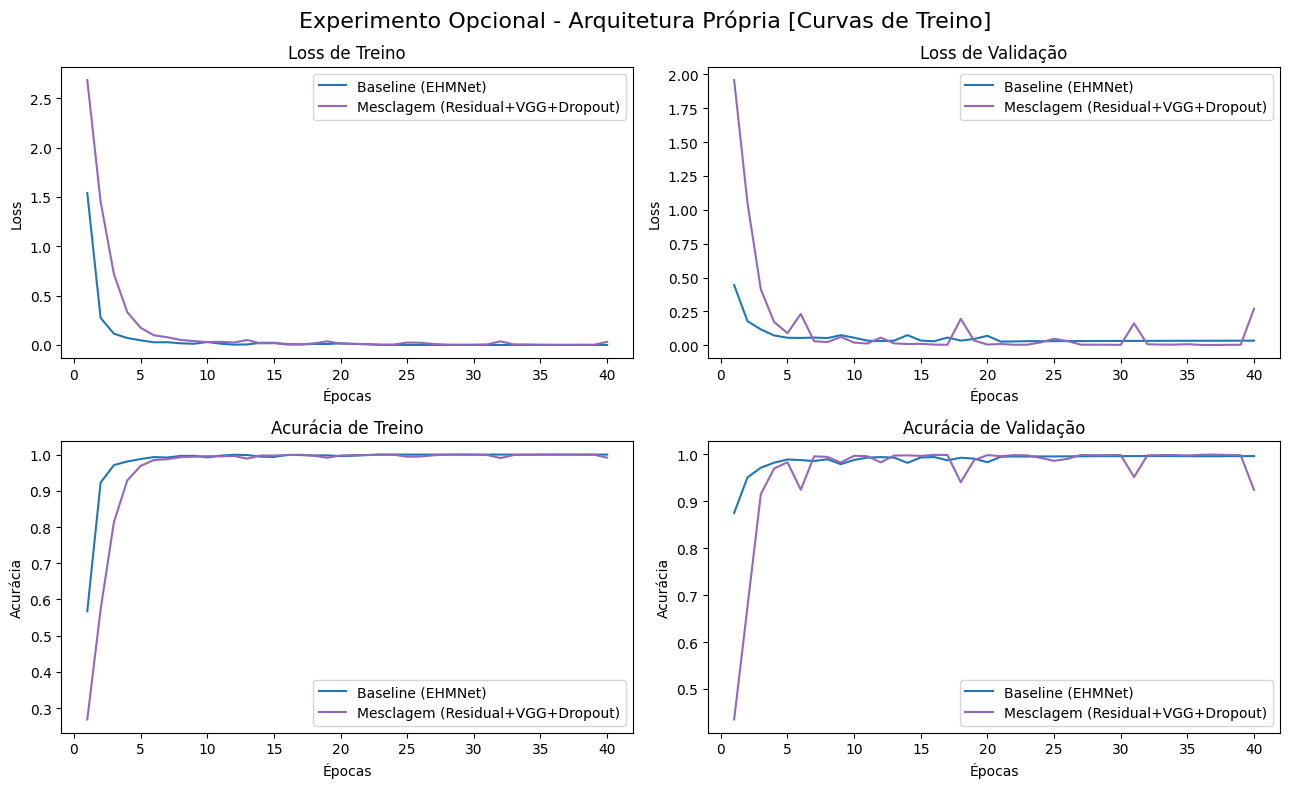

In [18]:
labels = {"baseline": "Baseline (EHMNet)", "mesclagem": "Mesclagem (Residual+VGG+Dropout)"}
colors = {"baseline": "tab:blue", "mesclagem": "tab:purple"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
axes[0, 0].set_title("Loss de Treino"); axes[0, 0].set_xlabel("Épocas"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
axes[0, 1].set_title("Loss de Validação"); axes[0, 1].set_xlabel("Épocas"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
axes[1, 0].set_title("Acurácia de Treino"); axes[1, 0].set_xlabel("Épocas"); axes[1, 0].set_ylabel("Acurácia"); axes[1, 0].legend()

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
axes[1, 1].set_title("Acurácia de Validação"); axes[1, 1].set_xlabel("Épocas"); axes[1, 1].set_ylabel("Acurácia"); axes[1, 1].legend()

plt.suptitle("Experimento Opcional - Arquitetura Própria [Curvas de Treino]", fontsize=16)
plt.tight_layout()
plt.savefig("figs/curvas_treino_arquitetura_propria.png", dpi=150, bbox_inches="tight")
plt.show()


### 2. Matrizes de confusão dos dois modelos

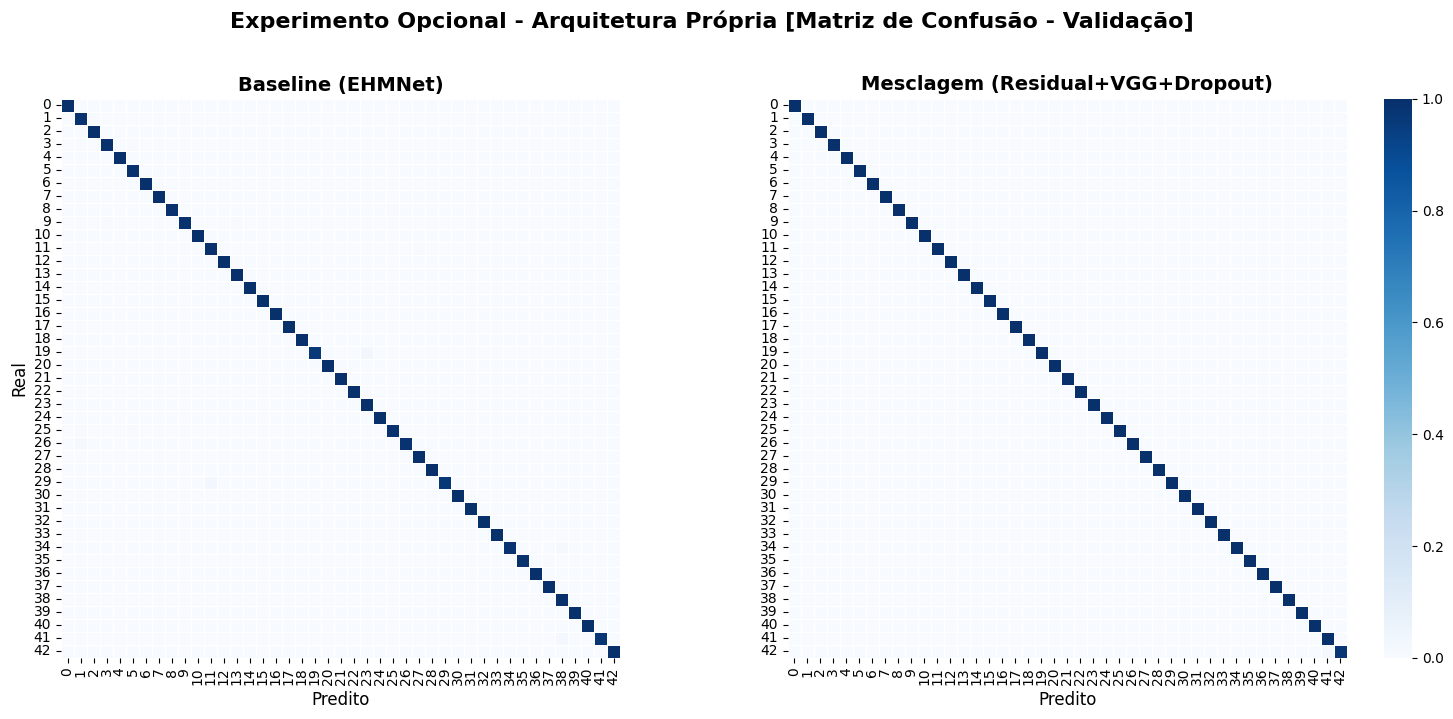

In [19]:
cm = {name: get_confusion_matrix(val_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
      for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, name in enumerate(["baseline", "mesclagem"]):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento Opcional - Arquitetura Própria [Matriz de Confusão - Validação]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figs/matrizes_confusao_comparacao_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Acurácia por classe e macro accuracy

In [20]:
relatorios = {}
for name in ["baseline", "mesclagem"]:
    relatorios[name] = relatorio_por_classe(cm[name], nome_modelo=labels[name])


=== Baseline (EHMNet) ===
Acurácia global (overall): 0.9964
Macro accuracy (média por classe): 0.9958

5 piores classes:
              classe  suporte  acertos  acuracia
Dangerous curve left       31       30    0.9677
   Bicycles crossing       32       31    0.9688
   End of no passing       40       39    0.9750
     Turn left ahead       68       67    0.9853
Speed limit (30km/h)      299      295    0.9866

5 melhores classes:
                     classe  suporte  acertos  acuracia
       Speed limit (20km/h)       26       26       1.0
       Speed limit (50km/h)      296      296       1.0
       Speed limit (70km/h)      269      269       1.0
      No passing veh > 3.5t      281      281       1.0
End of speed limit (80km/h)       63       63       1.0

=== Mesclagem (Residual+VGG+Dropout) ===
Acurácia global (overall): 0.9996
Macro accuracy (média por classe): 0.9994

5 piores classes:
                   classe  suporte  acertos  acuracia
End no passing veh > 3.5t       43   

In [21]:
metrics_results = {}

for name, r in all_results.items():
    ytrue, ypred = predict(val_loader, r["model"], device)

    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    metrics_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    print(f"{labels[name]}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")


Baseline (EHMNet):
  Acurácia Global: 0.9964
  Acurácia Macro:  0.9958

Mesclagem (Residual+VGG+Dropout):
  Acurácia Global: 0.9996
  Acurácia Macro:  0.9994



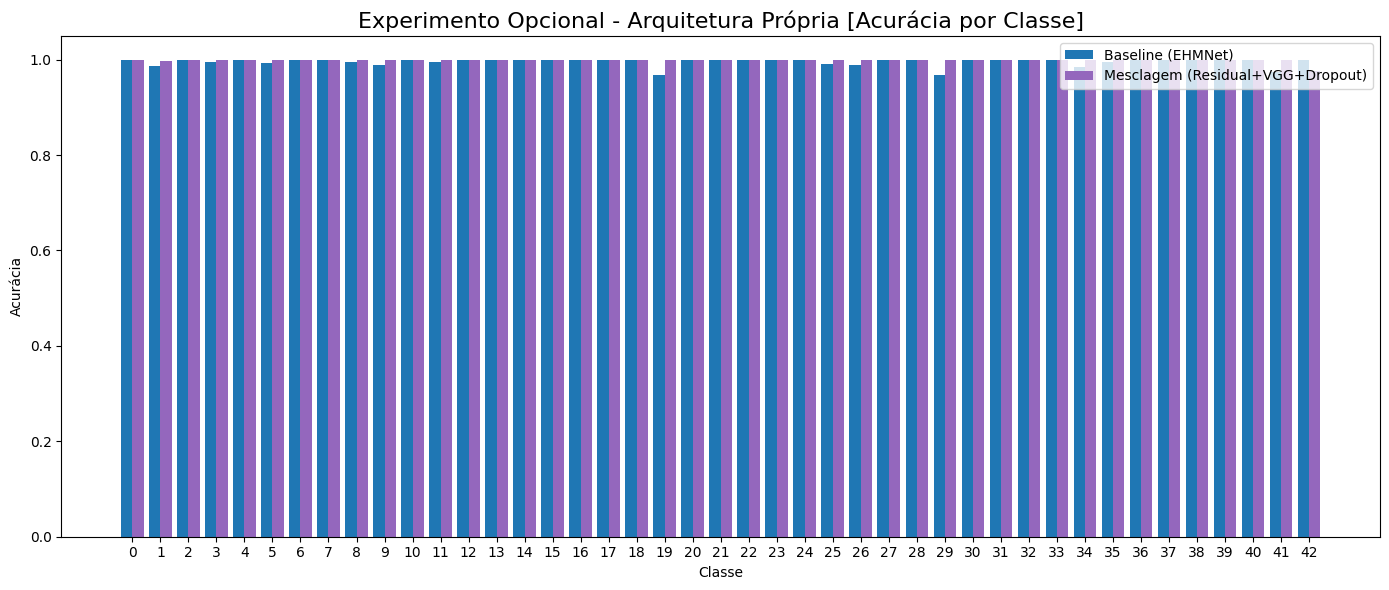

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
n_series = len(metrics_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(metrics_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(x + offset, r["per_class_acc"], width=width, label=labels[name], color=colors[name])

ax.set_xlabel("Classe")
ax.set_ylabel("Acurácia")
ax.set_title("Experimento Opcional - Arquitetura Própria [Acurácia por Classe]", fontsize=16)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig("figs/acuracia_por_classe_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


### 4. Predições no conjunto de teste

In [23]:
def predict_test_set(test_loader, model, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            predictions.extend(preds)
    return predictions

y_pred_baseline = predict_test_set(test_loader, all_results["baseline"]["model"], device)
save_predictions(y_pred_baseline, "predicoes_baseline_opcional.csv", experiment_name="EHMNet baseline (experimento opcional)")

y_pred_mesclagem = predict_test_set(test_loader, all_results["mesclagem"]["model"], device)
save_predictions(y_pred_mesclagem, "predicoes_arquitetura_propria.csv", experiment_name="EHMNet_Mesclagem (Residual+VGG+Dropout)")


# Métricas oficiais no conjunto de TESTE (avaliação final)

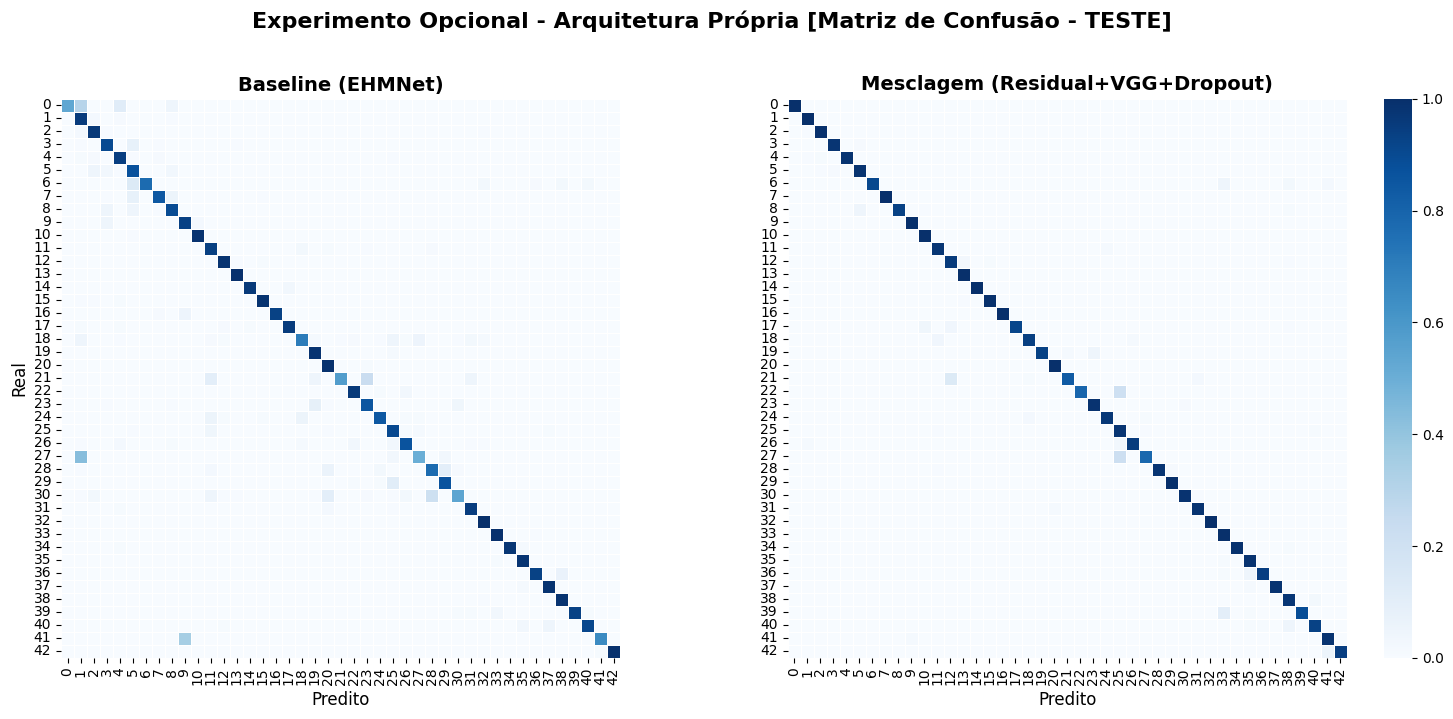

In [24]:
cm_test = {name: get_confusion_matrix(test_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
           for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, name in enumerate(["baseline", "mesclagem"]):
    cm_norm = cm_test[name].astype(float) / cm_test[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento Opcional - Arquitetura Própria [Matriz de Confusão - TESTE]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figs/matrizes_confusao_teste_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
relatorios_teste = {}
for name in ["baseline", "mesclagem"]:
    relatorios_teste[name] = relatorio_por_classe(cm_test[name], nome_modelo=f"{labels[name]} (TESTE)")

metrics_results_teste = {}
for name, r in all_results.items():
    ytrue, ypred = predict(test_loader, r["model"], device)
    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())
    metrics_results_teste[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }
    print(f"{labels[name]} (TESTE):")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")

resumo_final = pd.DataFrame({
    "modelo": [labels["baseline"], labels["mesclagem"]],
    "acuracia_global_val":   [round(metrics_results["baseline"]["global_acc"], 4), round(metrics_results["mesclagem"]["global_acc"], 4)],
    "acuracia_global_teste": [round(metrics_results_teste["baseline"]["global_acc"], 4), round(metrics_results_teste["mesclagem"]["global_acc"], 4)],
    "macro_accuracy_val":    [round(metrics_results["baseline"]["macro_acc"], 4), round(metrics_results["mesclagem"]["macro_acc"], 4)],
    "macro_accuracy_teste":  [round(metrics_results_teste["baseline"]["macro_acc"], 4), round(metrics_results_teste["mesclagem"]["macro_acc"], 4)],
})
print(resumo_final.to_string(index=False))


=== Baseline (EHMNet) (TESTE) ===
Acurácia global (overall): 0.9194
Macro accuracy (média por classe): 0.8835

5 piores classes:
              classe  suporte  acertos  acuracia
         Pedestrians       60       30    0.5000
Speed limit (20km/h)       60       32    0.5333
  Beware of ice/snow      150       81    0.5400
        Double curve       90       52    0.5778
   End of no passing       60       39    0.6500

5 melhores classes:
                    classe  suporte  acertos  acuracia
End speed + passing limits       60       60    1.0000
          Turn right ahead      210      209    0.9952
                     Yield      720      716    0.9944
     Dangerous curve right       90       89    0.9889
 End no passing veh > 3.5t       90       89    0.9889

=== Mesclagem (Residual+VGG+Dropout) (TESTE) ===
Acurácia global (overall): 0.9740
Macro accuracy (média por classe): 0.9617

5 piores classes:
                     classe  suporte  acertos  acuracia
                Pedestria

### Overfitting --> comparação entre treino e validação

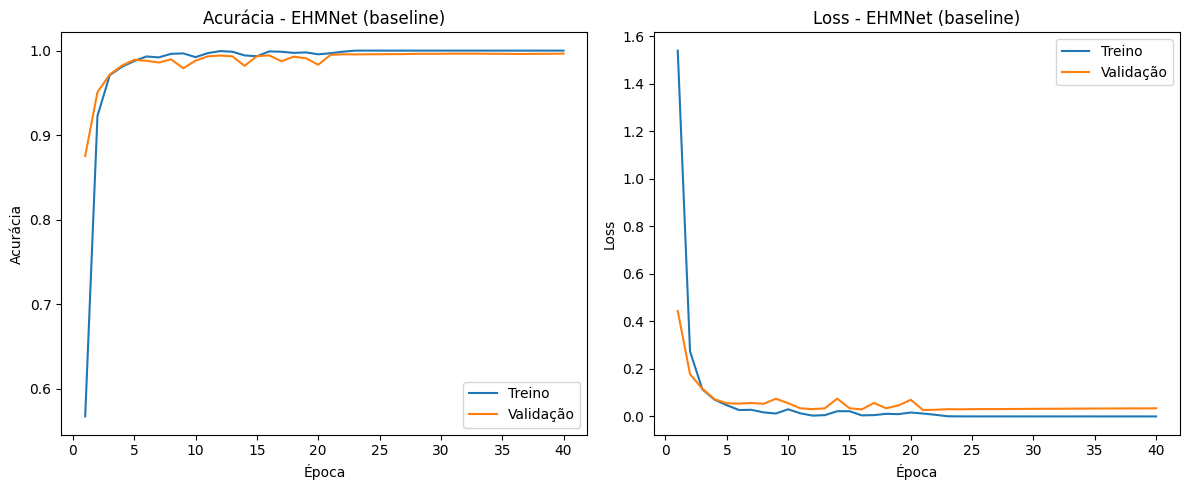

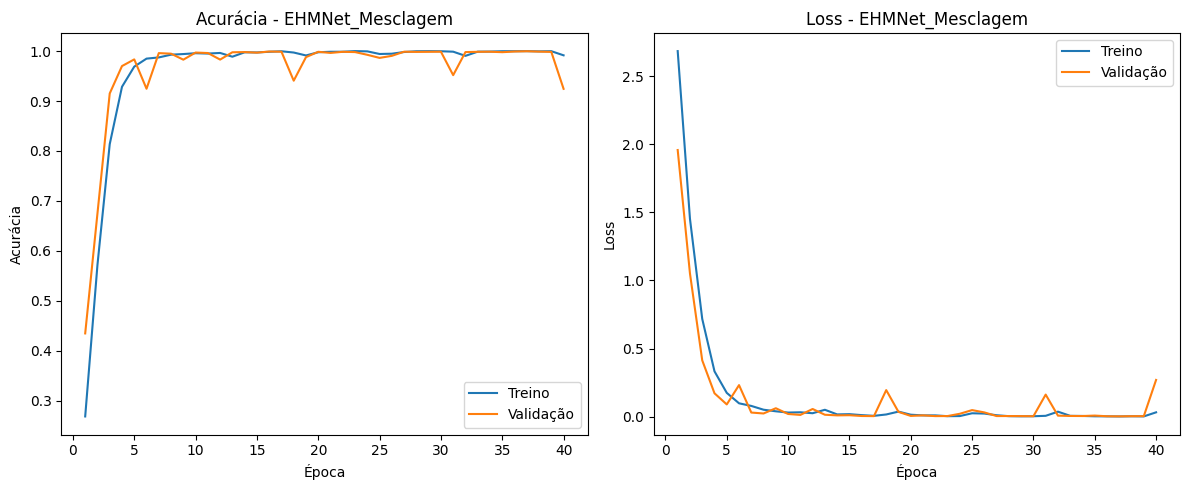

In [26]:
def plot_overfitting_check(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Treino')
    plt.plot(epochs, history['val_acc'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.title(f'Acurácia - {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Treino')
    plt.plot(epochs, history['val_loss'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"figs/overfitting_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_check(res_baseline["history"], "EHMNet (baseline)")
plot_overfitting_check(res_mesclagem["history"], "EHMNet_Mesclagem")
